In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv('movies.csv')

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv('movies.csv')
df.head(10)

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,37.2512,8.713,29484
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,30.7590,8.685,22254
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,14.5889,8.571,13460
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,14.1156,8.565,16977
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,11.8666,8.551,9637
5,5,129,Spirited Away,"A young girl, Chihiro, becomes trapped in a st...",2001-07-20,18.6650,8.500,17796
6,6,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,2008-07-16,24.4177,8.525,34957
7,7,19404,Dilwale Dulhania Le Jayenge,"Raj is a rich, carefree, happy-go-lucky second...",1995-10-20,6.5923,8.517,4538
8,8,497,The Green Mile,A supernatural tale set on death row in a Sout...,1999-12-10,17.6737,8.503,18699
9,9,496243,Parasite,"All unemployed, Ki-taek's family takes peculia...",2019-05-30,25.4246,8.496,19921


In [3]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year



In [4]:
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
id              0
title           0
overview        1
release_date    2
popularity      0
vote_average    0
vote_count      0
release_year    2
dtype: int64


In [5]:
import numpy as np


df_missing = df.copy()
df_missing['gross'] = df['vote_count'] * 1000 

df_missing.loc[0:9, 'gross'] = np.nan

df_imputed_mean = df_missing.copy()
df_imputed_mean['gross'] = df_imputed_mean['gross'].fillna(df_imputed_mean['gross'].mean())

df_imputed_median = df_missing.copy()
df_imputed_median['gross'] = df_imputed_median['gross'].fillna(df_imputed_median['gross'].median())

print("Missing values after Mean Imputation:", df_imputed_mean['gross'].isna().sum())

Missing values after Mean Imputation: 0


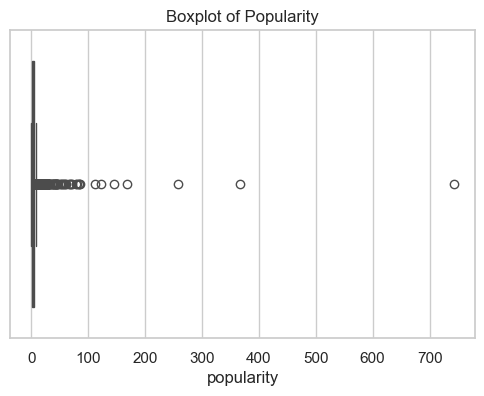

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['popularity'])
plt.title("Boxplot of Popularity")
plt.show()

In [7]:
 Q1 = df['popularity'].quantile(0.25)
Q3 = df['popularity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['popularity'] >= lower_bound) & (df['popularity'] <= upper_bound)]
print("Shape before:", df.shape)
print("Shape after removing outliers:", df_clean.shape)

Shape before: (8560, 8)
Shape after removing outliers: (7967, 8)


In [8]:
lower_cap = df['popularity'].quantile(0.05)
upper_cap = df['popularity'].quantile(0.95)

df_capped = df.copy()
df_capped['popularity'] = df_capped['popularity'].clip(lower_cap, upper_cap)

print("Original Min:", df['popularity'].min(), "Max:", df['popularity'].max())
print("Capped Min:", df_capped['popularity'].min(), "Max:", df_capped['popularity'].max())

Original Min: 0.0044 Max: 742.6667
Capped Min: 0.852365 Max: 10.807569999999973


In [9]:
df['popularity_minmax'] = (df['popularity'] - df['popularity'].min()) / (df['popularity'].max() - df['popularity'].min())

df['popularity_zscore'] = (df['popularity'] - df['popularity'].mean()) / df['popularity'].std()

print(df[['popularity', 'popularity_minmax', 'popularity_zscore']].head())

   popularity  popularity_minmax  popularity_zscore
0     37.2512           0.050153           3.038948
1     30.7590           0.041411           2.441155
2     14.5889           0.019638           0.952235
3     14.1156           0.019001           0.908655
4     11.8666           0.015973           0.701570


Explained variance ratio: [9.99999898e-01 7.74951479e-08]
            PC1       PC2
0  27255.650897  1.254068
1  20025.650879  1.146124
2  11231.650803  0.250623
3  14748.650789 -0.031734
4   7408.650798  0.258743


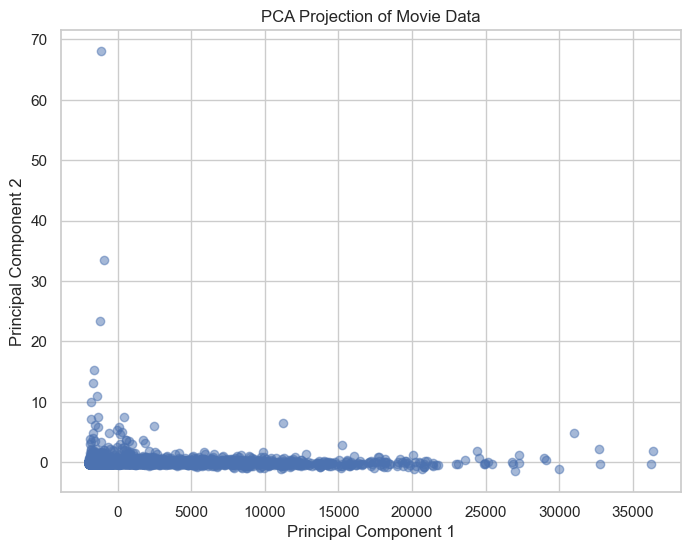

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

features = ['popularity_zscore', 'vote_average', 'vote_count']
x = df[features].fillna(df[features].median())

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)

pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(pca_df.head())



plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Movie Data')
plt.show()